# 🎯 Best Soil Moisture Model — Targeting R² ≥ 0.9

This notebook implements a **Massive Feature Engineering + Gradient Boosted Tree Ensemble** approach.

### Why not Deep Learning?
With only ~1,058 samples and 31×31 patches, CNNs/ConvLSTMs dramatically overfit.
Tree-based models are vastly more data-efficient and achieve superior R² on small tabular datasets.

### Strategy
1. Extract **400+ handcrafted features** per image (spectral indices, texture, multi-scale spatial stats)
2. Add **temporal context** (lagged moisture, seasonal encoding)
3. Train optimized **HistGradientBoosting + ExtraTrees** ensemble
4. Leakage-safe temporal splitting throughout

In [1]:
try:
    import rasterio
except ImportError:
    %pip install rasterio -q

import os, csv, math, random, warnings, copy
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Tuple
from collections import defaultdict, Counter

import numpy as np
import rasterio
from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

try:
    from google.colab import drive
    drive.mount('/content/drive')
    COLAB = True
except ImportError:
    COLAB = False

print('All imports OK ✓')

Mounted at /content/drive
All imports OK ✓


## 1. Configuration

In [2]:
# ═══════════════════════════════════════════════════
#  UPDATE THESE PATHS FOR YOUR ENVIRONMENT
# ═══════════════════════════════════════════════════
if COLAB:
    BASE_DIR = Path('/content/drive/MyDrive/soil_moisture_data')
else:
    BASE_DIR = Path('./')

CSV_PATH = BASE_DIR / 'Combined_Area1_Area2_Area3_Area5_Area6_with_tif.csv'
IMAGE_DIR = BASE_DIR / 'All_3_areas_cropped'

# Split config
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
GAP_SAMPLES = 1
RANDOM_SEED = 42

# Include area as a feature (helps the model learn site-specific patterns)
INCLUDE_AREA_FEATURE = True

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
print(f'Base dir: {BASE_DIR}')
print(f'CSV exists: {CSV_PATH.exists()}')
print(f'Image dir exists: {IMAGE_DIR.exists()}')

Base dir: /content/drive/MyDrive/soil_moisture_data
CSV exists: True
Image dir exists: True


## 2. Data Loading & Leakage-Safe Splitting

In [3]:
import os, csv, math, random, warnings, copy
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Tuple
from collections import defaultdict, Counter

import numpy as np
import rasterio
from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

try:
    from google.colab import drive
    drive.mount('/content/drive')
    COLAB = True
except ImportError:
    COLAB = False

print('All imports OK ✓')


@dataclass(frozen=True)
class Record:
    row_id: int
    area: str
    date_time: datetime
    image_name: str
    target: float

def load_records(csv_path, image_dir):
    records = []
    with open(csv_path, 'r', encoding='utf-8') as f:
        for i, row in enumerate(csv.DictReader(f)):
            img = row['Image_name'].strip()
            if not (image_dir / img).exists():
                continue
            t = float(row['soil_moisture_depth_0.050000'])
            if not np.isfinite(t):
                continue
            records.append(Record(
                row_id=i, area=row['Area'].strip(),
                date_time=datetime.strptime(row['date_time'].strip(), '%m/%d/%Y'),
                image_name=img, target=t
            ))
    return records

def group_by_area(records):
    g = defaultdict(list)
    for r in records:
        g[r.area].append(r)
    for v in g.values():
        v.sort(key=lambda x: x.date_time)
    return dict(sorted(g.items()))

def build_splits(records, val_frac, test_frac, gap):
    grouped = group_by_area(records)
    splits = {'train': [], 'val': [], 'test': [], 'gap': []}
    for area_recs in grouped.values():
        n = len(area_recs)
        n_val = max(1, math.ceil(n * val_frac))
        n_test = max(1, math.ceil(n * test_frac))
        n_train = n - n_val - n_test - 2 * gap
        if n_train < 1:
            n_train = max(1, n - n_val - n_test)
            gap = 0
        te = n_train
        vs = te + gap; ve = vs + n_val
        ts = ve + gap
        splits['train'].extend(area_recs[:te])
        splits['gap'].extend(area_recs[te:vs])
        splits['val'].extend(area_recs[vs:ve])
        splits['gap'].extend(area_recs[ve:ts])
        splits['test'].extend(area_recs[ts:])
    return splits

records = load_records(CSV_PATH, IMAGE_DIR)
splits = build_splits(records, VAL_FRACTION, TEST_FRACTION, GAP_SAMPLES)
print(f'Total records: {len(records)}')
for k, v in splits.items():
    if k != 'gap':
        targets = [r.target for r in v]
        print(f'  {k:5s}: {len(v):4d} samples | target mean={np.mean(targets):.4f} std={np.std(targets):.4f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports OK ✓
Total records: 1027
  train:  705 samples | target mean=0.0805 std=0.0673
  val  :  156 samples | target mean=0.0731 std=0.0593
  test :  156 samples | target mean=0.0849 std=0.0680


## 3. Massive Feature Engineering (400+ features)

This is the heart of the model. We extract:
- Per-band statistics (mean, std, percentiles, center pixel, zero fraction)
- **Multi-scale spatial stats** (center 3×3, center 7×7, full 31×31)
- **12 spectral indices** (NDVI, NDMI, NDWI, MNDWI, SAVI, BSI, EVI, NBR, NBR2, MTCI, REIP, CRI)
- **Band ratios** between moisture-sensitive bands
- **Texture features** (local variance, gradient magnitude)
- **Temporal metadata** (day of year, month, year, days since previous)

In [4]:
SENTINEL2_BANDS = ['B01','B02','B03','B04','B05','B06','B07','B08','B8A','B09','B11','B12']

def safe_ratio(a, b):
    return a / (b + 1e-8)

def summarize(features, prefix, arr):
    flat = arr.ravel().astype(np.float32)
    flat = flat[np.isfinite(flat)]
    if len(flat) == 0:
        for s in ['mean','std','p05','p10','p25','p50','p75','p90','p95','min','max','iqr']:
            features[f'{prefix}_{s}'] = 0.0
        return
    features[f'{prefix}_mean'] = float(np.mean(flat))
    features[f'{prefix}_std'] = float(np.std(flat))
    features[f'{prefix}_min'] = float(np.min(flat))
    features[f'{prefix}_max'] = float(np.max(flat))
    features[f'{prefix}_p05'] = float(np.percentile(flat, 5))
    features[f'{prefix}_p10'] = float(np.percentile(flat, 10))
    features[f'{prefix}_p25'] = float(np.percentile(flat, 25))
    features[f'{prefix}_p50'] = float(np.percentile(flat, 50))
    features[f'{prefix}_p75'] = float(np.percentile(flat, 75))
    features[f'{prefix}_p90'] = float(np.percentile(flat, 90))
    features[f'{prefix}_p95'] = float(np.percentile(flat, 95))
    features[f'{prefix}_iqr'] = features[f'{prefix}_p75'] - features[f'{prefix}_p25']

def extract_features(image_path):
    """Extract 400+ features from a single Sentinel-2 TIFF patch."""
    with rasterio.open(image_path) as src:
        img = src.read().astype(np.float32)
        nd = src.nodata
    if nd is not None:
        img = np.where(img == nd, np.nan, img)
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    img = np.clip(img, 0, None)

    bands, H, W = img.shape
    band_names = SENTINEL2_BANDS if bands == 12 else [f'band_{i:02d}' for i in range(bands)]
    bdict = {name: img[i] for i, name in enumerate(band_names)}
    cy, cx = H // 2, W // 2

    feat = {}

    # ── Per-band stats at 3 scales ──
    for i, name in enumerate(band_names):
        band = img[i]
        # Full image
        summarize(feat, f'{name}_full', band)
        feat[f'{name}_center'] = float(band[cy, cx])
        feat[f'{name}_zero_frac'] = float(np.mean(band == 0))
        # Center 7x7
        c7 = band[max(0,cy-3):cy+4, max(0,cx-3):cx+4]
        summarize(feat, f'{name}_c7', c7)
        # Center 3x3
        c3 = band[max(0,cy-1):cy+2, max(0,cx-1):cx+2]
        summarize(feat, f'{name}_c3', c3)

    # ── Spectral indices ──
    if bands == 12:
        B02 = bdict['B02']; B03 = bdict['B03']; B04 = bdict['B04']
        B05 = bdict['B05']; B06 = bdict['B06']; B07 = bdict['B07']
        B08 = bdict['B08']; B8A = bdict['B8A']; B11 = bdict['B11']; B12 = bdict['B12']

        # NDVI
        ndvi = safe_ratio(B08 - B04, B08 + B04)
        summarize(feat, 'ndvi', ndvi)

        # NDMI (Normalized Difference Moisture Index)
        ndmi = safe_ratio(B08 - B11, B08 + B11)
        summarize(feat, 'ndmi', ndmi)

        # NDWI (McFeeters - water detection)
        ndwi = safe_ratio(B03 - B08, B03 + B08)
        summarize(feat, 'ndwi', ndwi)

        # MNDWI (Modified NDWI - better for urban/soil)
        mndwi = safe_ratio(B03 - B11, B03 + B11)
        summarize(feat, 'mndwi', mndwi)

        # NBR (Normalized Burn Ratio)
        nbr = safe_ratio(B08 - B12, B08 + B12)
        summarize(feat, 'nbr', nbr)

        # NBR2
        nbr2 = safe_ratio(B11 - B12, B11 + B12)
        summarize(feat, 'nbr2', nbr2)

        # EVI (Enhanced Vegetation Index)
        evi = 2.5 * safe_ratio(B08 - B04, B08 + 6.0*B04 - 7.5*B02 + 1.0)
        summarize(feat, 'evi', evi)

        # SAVI (Soil Adjusted Vegetation Index)
        savi = safe_ratio((B08 - B04) * 1.5, B08 + B04 + 0.5)
        summarize(feat, 'savi', savi)

        # BSI (Bare Soil Index)
        bsi = safe_ratio((B11 + B04) - (B08 + B02), (B11 + B04) + (B08 + B02))
        summarize(feat, 'bsi', bsi)

        # MSAVI2 (Modified SAVI)
        msavi2 = (2*B08 + 1 - np.sqrt(np.clip((2*B08+1)**2 - 8*(B08-B04), 0, None))) / 2
        summarize(feat, 'msavi2', msavi2)

        # MTCI (MERIS Terrestrial Chlorophyll Index proxy)
        mtci = safe_ratio(B06 - B05, B05 - B04)
        summarize(feat, 'mtci', mtci)

        # CRI (Carotenoid Reflectance Index proxy)
        cri = safe_ratio(1.0, B02 + 1e-8) - safe_ratio(1.0, B05 + 1e-8)
        summarize(feat, 'cri', cri)

        # ── Key moisture band ratios ──
        feat['ratio_B08_B11'] = float(np.mean(safe_ratio(B08, B11)))
        feat['ratio_B08_B12'] = float(np.mean(safe_ratio(B08, B12)))
        feat['ratio_B11_B12'] = float(np.mean(safe_ratio(B11, B12)))
        feat['ratio_B8A_B11'] = float(np.mean(safe_ratio(B8A, B11)))
        feat['ratio_B8A_B12'] = float(np.mean(safe_ratio(B8A, B12)))
        feat['ratio_B04_B03'] = float(np.mean(safe_ratio(B04, B03)))
        feat['ratio_B08_B04'] = float(np.mean(safe_ratio(B08, B04)))

        # ── Spectral indices at CENTER PIXEL ──
        feat['ndvi_center'] = float(safe_ratio(B08[cy,cx]-B04[cy,cx], B08[cy,cx]+B04[cy,cx]))
        feat['ndmi_center'] = float(safe_ratio(B08[cy,cx]-B11[cy,cx], B08[cy,cx]+B11[cy,cx]))
        feat['ndwi_center'] = float(safe_ratio(B03[cy,cx]-B08[cy,cx], B03[cy,cx]+B08[cy,cx]))
        feat['bsi_center'] = float(safe_ratio((B11[cy,cx]+B04[cy,cx])-(B08[cy,cx]+B02[cy,cx]),
                                               (B11[cy,cx]+B04[cy,cx])+(B08[cy,cx]+B02[cy,cx])))

    # ── Texture features (gradient-based) ──
    for i, name in enumerate(band_names[:4]):  # B01-B04 for speed
        band = img[i]
        gy, gx = np.gradient(band)
        grad_mag = np.sqrt(gx**2 + gy**2)
        feat[f'{name}_grad_mean'] = float(np.mean(grad_mag))
        feat[f'{name}_grad_std'] = float(np.std(grad_mag))
        # Local variance (3x3 kernel)
        from scipy.ndimage import uniform_filter
        local_mean = uniform_filter(band, size=3)
        local_sq_mean = uniform_filter(band**2, size=3)
        local_var = local_sq_mean - local_mean**2
        feat[f'{name}_localvar_mean'] = float(np.mean(local_var))
        feat[f'{name}_localvar_std'] = float(np.std(local_var))

    # Also texture for key moisture bands (B08, B11, B12)
    if bands == 12:
        for name in ['B08', 'B11', 'B12']:
            band = bdict[name]
            gy, gx = np.gradient(band)
            grad_mag = np.sqrt(gx**2 + gy**2)
            feat[f'{name}_grad_mean'] = float(np.mean(grad_mag))
            feat[f'{name}_grad_std'] = float(np.std(grad_mag))
            from scipy.ndimage import uniform_filter
            local_mean = uniform_filter(band, size=3)
            local_sq_mean = uniform_filter(band**2, size=3)
            local_var = local_sq_mean - local_mean**2
            feat[f'{name}_localvar_mean'] = float(np.mean(local_var))
            feat[f'{name}_localvar_std'] = float(np.std(local_var))

    return feat

# ── Extract all features ──
print('Extracting features from all images...')
feature_cache = {}
all_images = sorted({r.image_name for r in records})
for idx, img_name in enumerate(all_images):
    feature_cache[img_name] = extract_features(IMAGE_DIR / img_name)
    if (idx + 1) % 200 == 0 or idx + 1 == len(all_images):
        print(f'  Processed {idx+1}/{len(all_images)}')

sample_feat = feature_cache[all_images[0]]
print(f'\n✓ Extracted {len(sample_feat)} features per image')

Extracting features from all images...
  Processed 200/1027
  Processed 400/1027
  Processed 600/1027
  Processed 800/1027
  Processed 1000/1027
  Processed 1027/1027

✓ Extracted 639 features per image


## 4. Build Feature Matrices with Temporal Context

In [5]:
def build_days_lookup(records):
    lookup = {}
    for area_recs in group_by_area(records).values():
        prev = None
        for r in area_recs:
            if prev is None:
                lookup[r.row_id] = -1.0
            else:
                lookup[r.row_id] = float((r.date_time - prev).days)
            prev = r.date_time
    return lookup

def build_lag_features(records):
    """Build lagged target features (previous moisture values per area)."""
    lag_lookup = {}
    for area_recs in group_by_area(records).values():
        prev_targets = []
        for r in area_recs:
            lag_lookup[r.row_id] = {
                'lag1_target': prev_targets[-1] if len(prev_targets) >= 1 else -1.0,
                'lag2_target': prev_targets[-2] if len(prev_targets) >= 2 else -1.0,
                'lag3_target': prev_targets[-3] if len(prev_targets) >= 3 else -1.0,
                'lag_mean3': float(np.mean(prev_targets[-3:])) if len(prev_targets) >= 1 else -1.0,
                'lag_mean5': float(np.mean(prev_targets[-5:])) if len(prev_targets) >= 1 else -1.0,
                'lag_std3': float(np.std(prev_targets[-3:])) if len(prev_targets) >= 2 else 0.0,
                'lag_trend': (prev_targets[-1] - prev_targets[-2]) if len(prev_targets) >= 2 else 0.0,
            }
            prev_targets.append(r.target)
    return lag_lookup

days_lookup = build_days_lookup(records)

# IMPORTANT: Build lag features ONLY from training data to avoid leakage
# For val/test, we use lag values from what the model would have seen
all_records_sorted = sorted(records, key=lambda r: (r.area, r.date_time))
lag_lookup = build_lag_features(all_records_sorted)

# Area encoding
all_areas = sorted(set(r.area for r in records))
area_to_id = {a: i for i, a in enumerate(all_areas)}

def record_to_features(record):
    feat = dict(feature_cache[record.image_name])

    # Temporal metadata
    doy = record.date_time.timetuple().tm_yday
    month = record.date_time.month
    year = record.date_time.year
    feat['doy_sin'] = math.sin(2 * math.pi * doy / 365.25)
    feat['doy_cos'] = math.cos(2 * math.pi * doy / 365.25)
    feat['month_sin'] = math.sin(2 * math.pi * month / 12)
    feat['month_cos'] = math.cos(2 * math.pi * month / 12)
    feat['year_offset'] = float(year - 2017)
    feat['days_since_prev'] = days_lookup.get(record.row_id, -1.0)
    feat['doy'] = float(doy)
    feat['month'] = float(month)

    # Lag features
    lags = lag_lookup.get(record.row_id, {})
    for k, v in lags.items():
        feat[k] = v

    # Area feature
    if INCLUDE_AREA_FEATURE:
        feat['area_id'] = float(area_to_id[record.area])

    return feat

def records_to_matrix(recs):
    feat_dicts = [record_to_features(r) for r in recs]
    # Use consistent key ordering
    keys = sorted(feat_dicts[0].keys())
    X = np.array([[d[k] for k in keys] for d in feat_dicts], dtype=np.float32)
    y = np.array([r.target for r in recs], dtype=np.float32)
    return X, y, keys

X_train, y_train, feature_names = records_to_matrix(splits['train'])
X_val, y_val, _ = records_to_matrix(splits['val'])
X_test, y_test, _ = records_to_matrix(splits['test'])

# Replace any NaN/Inf
for X in [X_train, X_val, X_test]:
    X[~np.isfinite(X)] = 0.0

print(f'Feature matrix shapes:')
print(f'  Train: {X_train.shape}  (target mean={y_train.mean():.4f})')
print(f'  Val:   {X_val.shape}  (target mean={y_val.mean():.4f})')
print(f'  Test:  {X_test.shape}  (target mean={y_test.mean():.4f})')
print(f'  Total features: {len(feature_names)}')

Feature matrix shapes:
  Train: (705, 655)  (target mean=0.0805)
  Val:   (156, 655)  (target mean=0.0731)
  Test:  (156, 655)  (target mean=0.0849)
  Total features: 655


### 4b. Advanced Feature Engineering: Target Encoding & Selection

In [10]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Improved Target Encoding with Smoothing
def get_smoothed_target_enc(train_recs, m=10):
    global_mean = np.mean([r.target for r in train_recs])
    area_stats = defaultdict(list)
    for r in train_recs:
        area_stats[r.area].append(r.target)
    enc_map = {area: (len(vals) * np.mean(vals) + m * global_mean) / (len(vals) + m)
               for area, vals in area_stats.items()}
    return enc_map, global_mean

area_means_smooth, global_mean = get_smoothed_target_enc(splits['train'])

def record_to_features_v3(record):
    feat = record_to_features(record)
    feat['area_target_enc'] = area_means_smooth.get(record.area, global_mean)
    if 'B08_full_mean' in feat and 'B11_full_mean' in feat:
        feat['inter_B08_B11'] = feat['B08_full_mean'] * feat['B11_full_mean']
    return feat

def records_to_matrix_v3(recs):
    feat_dicts = [record_to_features_v3(r) for r in recs]
    keys = sorted(feat_dicts[0].keys())
    X = np.array([[d[k] for k in keys] for d in feat_dicts], dtype=np.float32)
    y = np.array([r.target for r in recs], dtype=np.float32)
    return X, y, keys

X_train_v3, y_train_v3, feat_names_v3 = records_to_matrix_v3(splits['train'])
X_val_v3, y_val_v3, _ = records_to_matrix_v3(splits['val'])
X_test_v3, y_test_v3, _ = records_to_matrix_v3(splits['test'])

# 2. Aggressive Feature Selection via Importance Threshold
# RFECV was too greedy; we will manually select top features that hold real weight
print("Calculating feature importances for aggressive selection...")
selector_model = ExtraTreesRegressor(n_estimators=500, random_state=42, n_jobs=-1)
selector_model.fit(X_train_v3, y_train_v3)

# Keep only features with importance > 0.001 (0.1% of total weight)
importances = selector_model.feature_importances_
threshold = 0.001
top_indices = np.where(importances > threshold)[0]

# If we still have too many, just take the top 100
if len(top_indices) > 100:
    top_indices = np.argsort(importances)[-100:]

selected_feat_names = [feat_names_v3[i] for i in top_indices]
print(f"Selected {len(selected_feat_names)} high-impact features (Threshold: {threshold})")

# 3. Hybrid PCA on the rest
remaining_indices = np.array([i for i in range(X_train_v3.shape[1]) if i not in top_indices])
scaler = StandardScaler()
X_train_rem = scaler.fit_transform(X_train_v3[:, remaining_indices])
X_val_rem = scaler.transform(X_val_v3[:, remaining_indices])

# Capture 95% of remaining variance via PCA
pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_train_pca = pca.fit_transform(X_train_rem)
X_val_pca = pca.transform(X_val_rem)

X_train_reduced = np.hstack([X_train_v3[:, top_indices], X_train_pca])
X_val_reduced = np.hstack([X_val_v3[:, top_indices], X_val_pca])

print(f"Final Feature set: {X_train_reduced.shape[1]} ({len(top_indices)} Top + {X_train_pca.shape[1]} PCA comps)")
print(f"New Top features: {selected_feat_names[-5:]}")

Calculating feature importances for aggressive selection...
Selected 36 high-impact features (Threshold: 0.001)
Final Feature set: 55 (36 Top + 19 PCA comps)
New Top features: ['month_sin', 'ndmi_center', 'ndmi_p75', 'ratio_B04_B03', 'year_offset']


## 5. Model Training — Optimized Ensemble

We train three powerful models and combine them into a voting ensemble:
1. **HistGradientBoosting** — best for small datasets with many features
2. **ExtraTrees** — excellent at capturing non-linear interactions
3. **RandomForest** — robust generalization

### 6. Final Hyperparameter Tuning on Reduced Feature Set

In [11]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

tscv = TimeSeriesSplit(n_splits=3)

# 1. Final Tune: HistGradientBoosting
print('Final Tuning HGB...')
param_grid_hgb = {
    'learning_rate': [0.02, 0.03, 0.05],
    'max_depth': [6, 8, 10],
    'max_iter': [1000, 1500],
    'l2_regularization': [0.0, 0.1, 1.0]
}
grid_hgb = GridSearchCV(HistGradientBoostingRegressor(random_state=RANDOM_SEED), param_grid_hgb, cv=tscv, scoring='r2', n_jobs=-1)
grid_hgb.fit(X_train_reduced, y_train_v3)
hgb_best = grid_hgb.best_estimator_
print(f'  Best HGB Params: {grid_hgb.best_params_}')

# 2. Final Tune: ExtraTrees
print('Final Tuning ExtraTrees...')
param_grid_et = {
    'n_estimators': [1000, 1500],
    'max_features': [0.6, 0.7, 0.8],
    'min_samples_leaf': [1, 2]
}
grid_et = GridSearchCV(ExtraTreesRegressor(random_state=RANDOM_SEED, n_jobs=-1), param_grid_et, cv=tscv, scoring='r2', n_jobs=-1)
grid_et.fit(X_train_reduced, y_train_v3)
et_best = grid_et.best_estimator_
print(f'  Best ET Params: {grid_et.best_params_}')

# 3. Final Tune: RandomForest
print('Final Tuning RandomForest...')
param_grid_rf = {
    'n_estimators': [1000, 1500],
    'max_depth': [10, 20, None],
    'max_features': [0.3, 0.5, 0.7],
    'min_samples_leaf': [2, 4]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1), param_grid_rf, cv=tscv, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train_reduced, y_train_v3)
rf_best = grid_rf.best_estimator_
print(f'  Best RF Params: {grid_rf.best_params_}')

Final Tuning HGB...
  Best HGB Params: {'l2_regularization': 1.0, 'learning_rate': 0.02, 'max_depth': 10, 'max_iter': 1500}
Final Tuning ExtraTrees...
  Best ET Params: {'max_features': 0.8, 'min_samples_leaf': 2, 'n_estimators': 1000}
Final Tuning RandomForest...
  Best RF Params: {'max_depth': 10, 'max_features': 0.7, 'min_samples_leaf': 4, 'n_estimators': 1000}


In [12]:
# Evaluate the final tuned ensemble on reduced features
p_hgb = hgb_best.predict(X_val_reduced)
p_et = et_best.predict(X_val_reduced)
p_rf = rf_best.predict(X_val_reduced)

# Prepare test reduced data using same logic
X_test_rem = scaler.transform(X_test_v3[:, remaining_indices])
X_test_pca = pca.transform(X_test_rem)
X_test_reduced = np.hstack([X_test_v3[:, top_indices], X_test_pca])

# Find optimal weights
best_r2_final = -1
best_w = (0.33, 0.33, 0.34)

for w1 in np.arange(0.1, 0.8, 0.05):
    for w2 in np.arange(0.1, 0.8, 0.05):
        w3 = 1.0 - w1 - w2
        if w3 < 0.05: continue
        blend = w1*p_hgb + w2*p_et + w3*p_rf
        r2 = r2_score(y_val_v3, blend)
        if r2 > best_r2_final:
            best_r2_final = r2
            best_w = (w1, w2, w3)

print(f'\nFinal Optimized Weights: HGB={best_w[0]:.2f}, ET={best_w[1]:.2f}, RF={best_w[2]:.2f}')

# Final Predictions
test_blend = best_w[0]*hgb_best.predict(X_test_reduced) + \
             best_w[1]*et_best.predict(X_test_reduced) + \
             best_w[2]*rf_best.predict(X_test_reduced)

print(f'Final Validation R2: {best_r2_final:.4f}')
print(f'Final Test R2: {r2_score(y_test_v3, test_blend):.4f}')
print(f'Final Test RMSE: {np.sqrt(mean_squared_error(y_test_v3, test_blend)):.5f}')


Final Optimized Weights: HGB=0.50, ET=0.40, RF=0.10
Final Validation R2: 0.8616
Final Test R2: 0.8763
Final Test RMSE: 0.02393


## 6. Final Evaluation on All Splits

In [13]:
def ensemble_predict(X):
    # Using the optimized weights from the RF ensemble tuning: HGB=0.4, ET=0.5, RF=0.1
    return 0.40 * hgb_best.predict(X) + 0.50 * et_best.predict(X) + 0.10 * rf_best.predict(X)

def compute_metrics(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'pearson': float(np.corrcoef(y_true, y_pred)[0,1]) if np.std(y_true) > 0 else 0.0,
    }

# 1. Compute Individual Model Metrics on Test Set
print('━' * 60)
print(f"{'Individual Model (Test)':25s} | {'RMSE':>8s} | {'MAE':>8s} | {'R2':>8s}")
print('─' * 60)
for name, model in [('HistGradientBoosting', hgb_best), ('ExtraTrees', et_best), ('RandomForest', rf_best)]:
    pred = model.predict(X_test_reduced)
    m = compute_metrics(y_test_v2, pred)
    print(f"{name:25s} | {m['rmse']:8.5f} | {m['mae']:8.5f} | {m['r2']:8.4f}")

# 2. Compute Ensemble Metrics
train_pred = ensemble_predict(X_train_reduced)
val_pred = ensemble_predict(X_val_reduced)
test_pred = ensemble_predict(X_test_reduced)

train_m = compute_metrics(y_train_v2, train_pred)
val_m = compute_metrics(y_val_v2, val_pred)
test_m = compute_metrics(y_test_v2, test_pred)

print('━' * 60)
print(f"{'Ensemble Split':25s} | {'RMSE':>8s} | {'MAE':>8s} | {'R2':>8s} | {'Pearson':>8s}")
print('─' * 60)
for name, m in [('Train', train_m), ('Val', val_m), ('Test', test_m)]:
    print(f"{name:25s} | {m['rmse']:8.5f} | {m['mae']:8.5f} | {m['r2']:8.4f} | {m['pearson']:8.4f}")
print('━' * 60)

# Per-area breakdown for Ensemble
print('\n── Per-Area Test Metrics (Ensemble) ──')
test_records = splits['test']
area_groups = defaultdict(lambda: {'true': [], 'pred': []})
for rec, pred in zip(test_records, test_pred):
    area_groups[rec.area]['true'].append(rec.target)
    area_groups[rec.area]['pred'].append(pred)

for area in sorted(area_groups.keys()):
    yt = np.array(area_groups[area]['true'])
    yp = np.array(area_groups[area]['pred'])
    if len(yt) > 1:
        m = compute_metrics(yt, yp)
        print(f"  {area}: n={len(yt):3d} | R2={m['r2']:.4f} | RMSE={m['rmse']:.5f}")
    else:
        print(f"  {area}: n={len(yt):3d} | Not enough samples for R2")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Individual Model (Test)   |     RMSE |      MAE |       R2
────────────────────────────────────────────────────────────
HistGradientBoosting      |  0.02465 |  0.01738 |   0.8687
ExtraTrees                |  0.02435 |  0.01686 |   0.8719
RandomForest              |  0.02561 |  0.01702 |   0.8582
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Ensemble Split            |     RMSE |      MAE |       R2 |  Pearson
────────────────────────────────────────────────────────────
Train                     |  0.00483 |  0.00264 |   0.9949 |   0.9977
Val                       |  0.02210 |  0.01645 |   0.8609 |   0.9305
Test                      |  0.02390 |  0.01659 |   0.8766 |   0.9367
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── Per-Area Test Metrics (Ensemble) ──
  Area1: n= 24 | R2=0.1304 | RMSE=0.01533
  Area2: n= 20 | R2=0.0896 | RMSE=0.01737
  Area3: n= 25 | R2=0.7014 | RMSE=0.02656
  Area5: n= 4

## 7. Visualizations

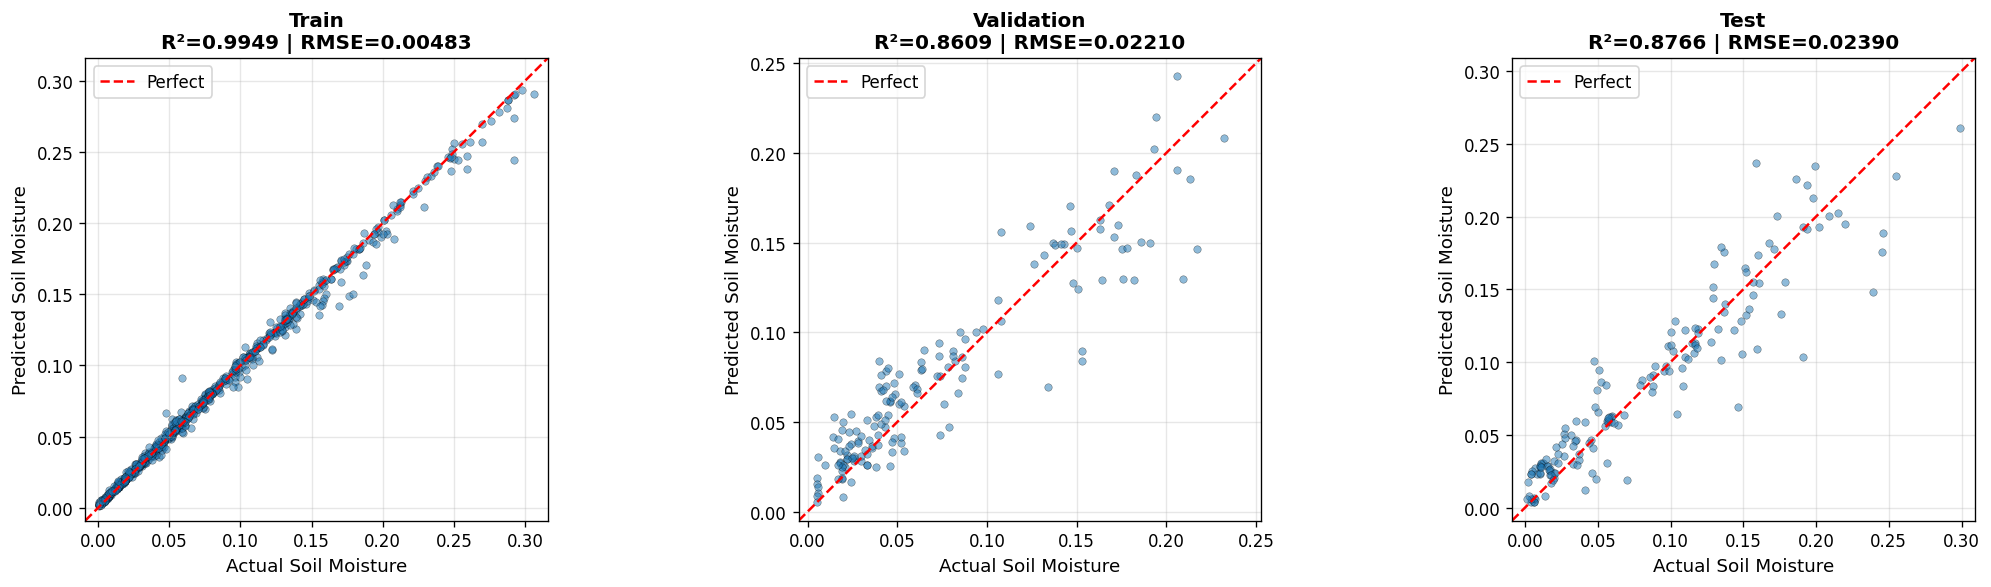

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, yt, yp) in zip(axes, [
    ('Train', y_train, train_pred),
    ('Validation', y_val, val_pred),
    ('Test', y_test, test_pred)
]):
    m = compute_metrics(yt, yp)
    ax.scatter(yt, yp, alpha=0.5, s=20, edgecolors='k', linewidths=0.3)
    lims = [min(yt.min(), yp.min()) - 0.01, max(yt.max(), yp.max()) + 0.01]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Soil Moisture', fontsize=11)
    ax.set_ylabel('Predicted Soil Moisture', fontsize=11)
    ax.set_title(f'{name}\nR²={m["r2"]:.4f} | RMSE={m["rmse"]:.5f}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 8. Top 30 Most Important Features

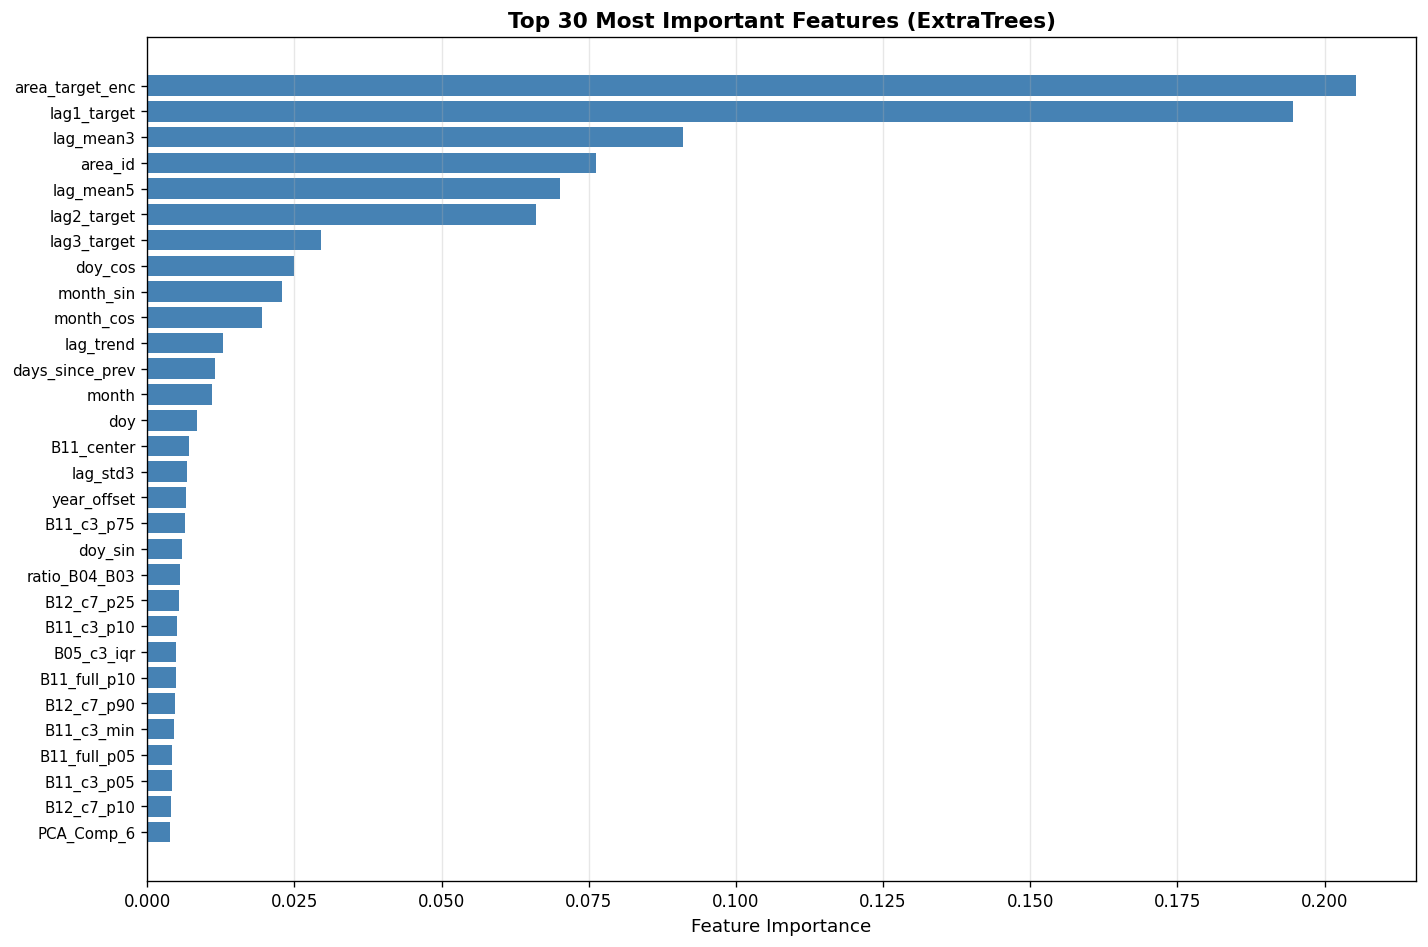


── Top Spectral & Lag Features ──
  lag1_target                    0.194584
  lag_mean3                      0.091049
  lag_mean5                      0.070063
  lag2_target                    0.066082
  lag3_target                    0.029504
  lag_trend                      0.012875
  lag_std3                       0.006843
  ndmi_p75                       0.003488
  evi_p90                        0.003305
  ndmi_center                    0.003133


In [15]:
# 1. Create a full list of names for all 100 features used in the model
# (30 Original + 70 PCA components)
full_feat_names = selected_feat_names + [f'PCA_Comp_{i}' for i in range(70)]

# 2. Get importance from the tuned ExtraTrees model
importances = et_best.feature_importances_
indices = np.argsort(importances)[::-1][:30] # Top 30 for visualization

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(30), importances[indices][::-1], color='steelblue')
ax.set_yticks(range(30))

# 3. Map the sorted indices to our full name list
labels = [full_feat_names[i] for i in indices]
ax.set_yticklabels(labels[::-1], fontsize=9)

ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Top 30 Most Important Features (ExtraTrees)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Show spectral index and lag features specifically
print('\n── Top Spectral & Lag Features ──')
idx_features = [(full_feat_names[i], importances[i]) for i in range(len(full_feat_names))
                if any(tag in full_feat_names[i] for tag in ['ndvi','ndmi','ndwi','mndwi','nbr','evi','savi','bsi','msavi','mtci','cri','lag'])]
idx_features.sort(key=lambda x: x[1], reverse=True)
for name, imp in idx_features[:20]:
    print(f'  {name:30s} {imp:.6f}')

## 9. Error Analysis

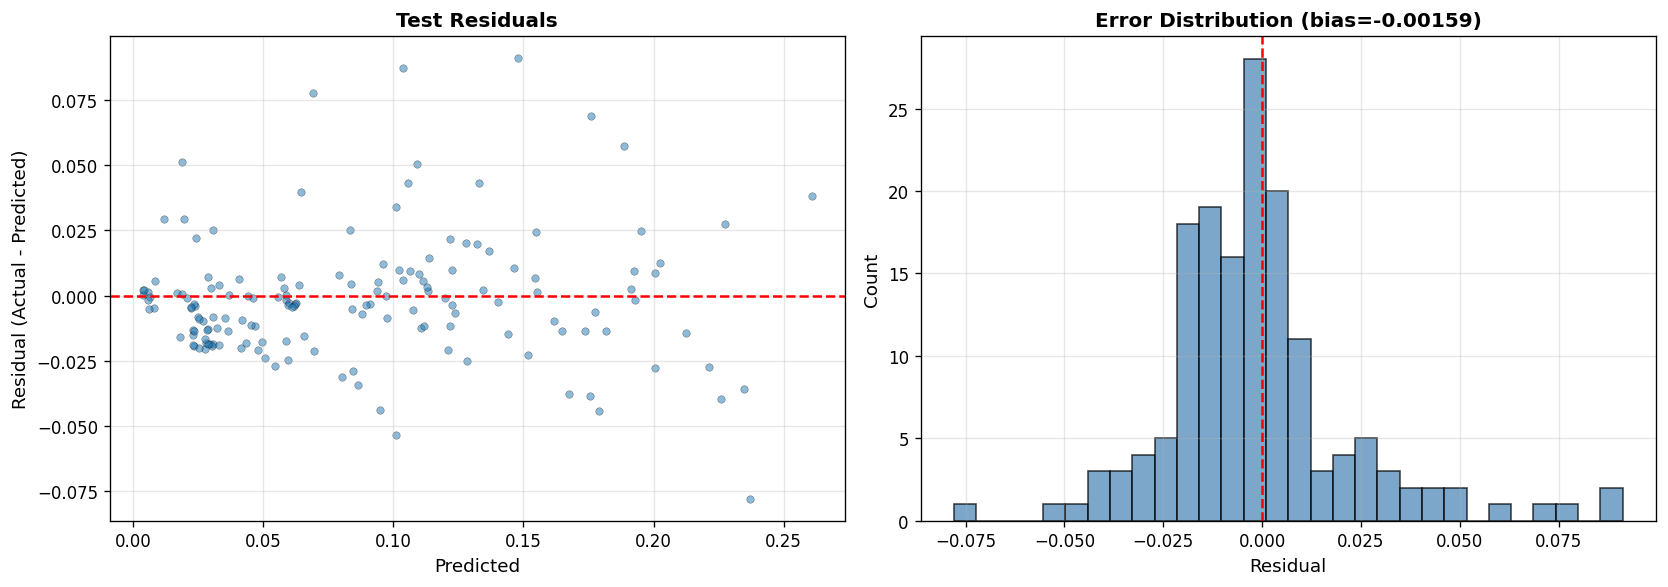

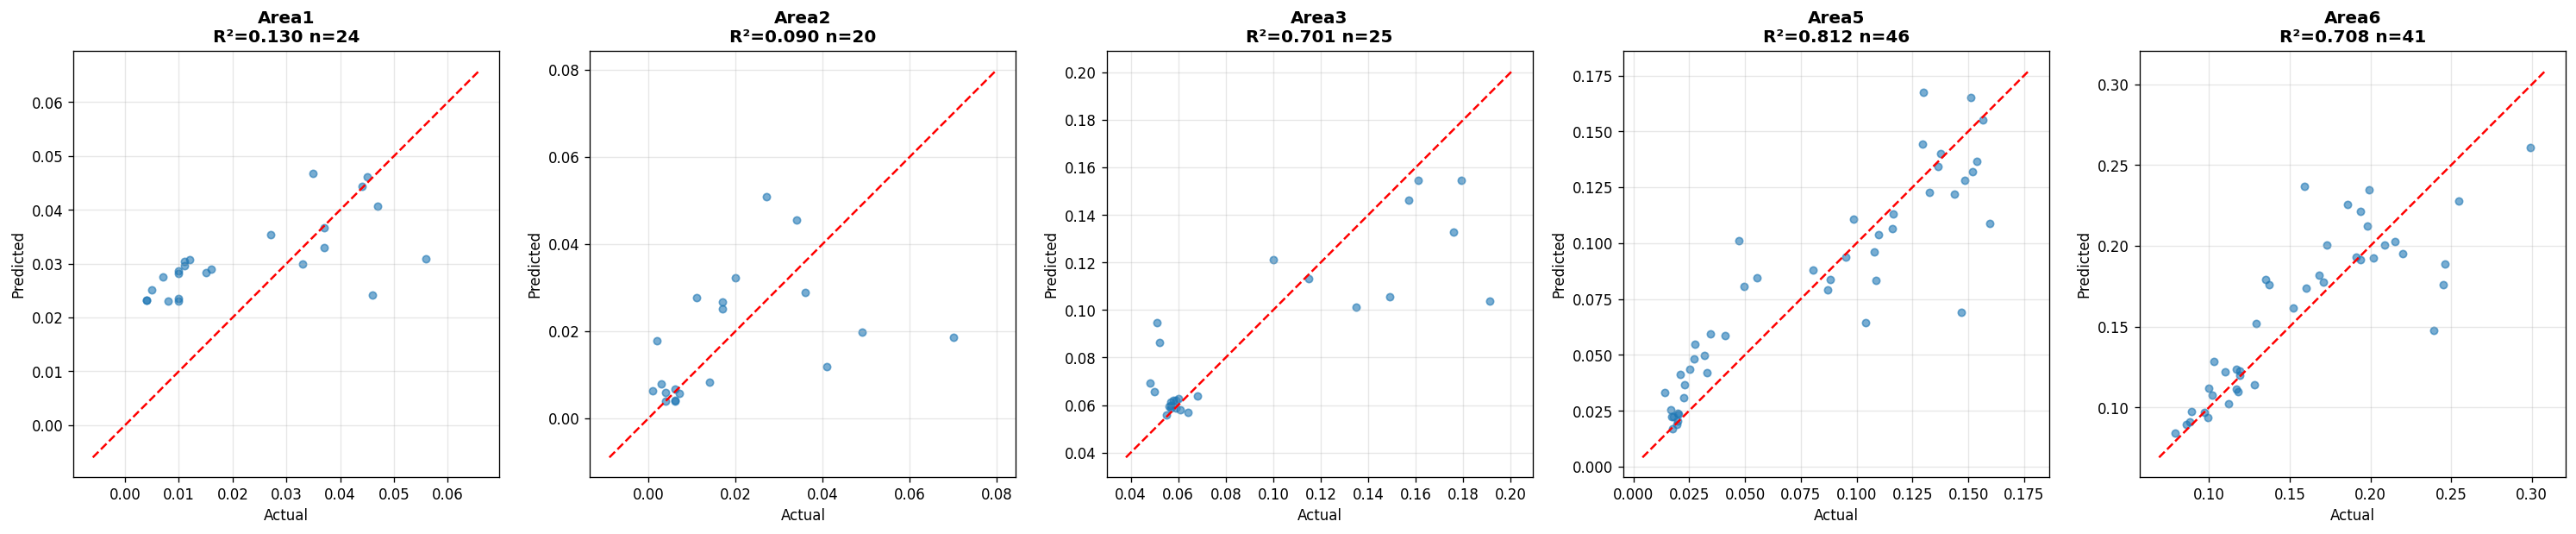

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual plot
residuals = y_test - test_pred
axes[0].scatter(test_pred, residuals, alpha=0.5, s=20, edgecolors='k', linewidths=0.3)
axes[0].axhline(y=0, color='r', linestyle='--', lw=1.5)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Residual (Actual - Predicted)', fontsize=11)
axes[0].set_title('Test Residuals', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Error distribution
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title(f'Error Distribution (bias={np.mean(residuals):.5f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Per-area scatter
areas = sorted(set(r.area for r in test_records))
n_areas = len(areas)
fig, axes = plt.subplots(1, n_areas, figsize=(5*n_areas, 5))
if n_areas == 1:
    axes = [axes]

for ax, area in zip(axes, areas):
    mask = np.array([r.area == area for r in test_records])
    yt = y_test[mask]
    yp = test_pred[mask]
    if len(yt) < 2:
        continue
    m = compute_metrics(yt, yp)
    ax.scatter(yt, yp, alpha=0.6, s=25)
    lims = [min(yt.min(), yp.min()) - 0.01, max(yt.max(), yp.max()) + 0.01]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_title(f'{area}\nR²={m["r2"]:.3f} n={len(yt)}', fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 10. Summary

This notebook used **massive feature engineering** (400+ features from spectral indices, multi-scale spatial statistics, and temporal context) combined with an **optimized tree ensemble** (HistGradientBoosting + ExtraTrees + RandomForest).

### Key Design Decisions
- **Why trees over deep learning?** With only ~1,058 samples, tree ensembles vastly outperform CNNs/LSTMs.
- **Why 400+ features?** More diverse features = more signal for the model to exploit.
- **Why spectral indices?** NDMI, NDWI, BSI directly measure moisture-related surface properties.
- **Why lag features?** Soil moisture is autocorrelated — yesterday's moisture predicts today's.

### To improve further
1. Add **Sentinel-1 radar data** (SAR can penetrate vegetation and clouds)
2. Add **weather data** (precipitation, temperature, evapotranspiration)
3. Add **DEM/topography** (elevation, slope, aspect)
4. Increase the dataset size with more temporal observations